In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
from collections import defaultdict
from tqdm import tqdm

In [8]:
G = nx.DiGraph()
nodes = [chr(x) for x in range(ord("a"),ord("z"))]
for n in nodes:
    npeers = 5
    neighbours = [p for p in random.sample(nodes,3) if p != n]
    weights = np.array([random.random()**2 for _ in neighbours])
    weights = weights / weights.sum()
    #print(weights)
    for p, w in zip(neighbours, weights):
        G.add_edge(n,p, weight=w)
    #break

{('a', 'e'): '0.12', ('a', 'p'): '0.28', ('a', 'd'): '0.60', ('e', 't'): '0.19', ('e', 'f'): '0.39', ('e', 'w'): '0.42', ('p', 'c'): '0.01', ('p', 'i'): '0.38', ('p', 'r'): '0.61', ('d', 'i'): '0.29', ('d', 'c'): '0.16', ('d', 'l'): '0.54', ('b', 'j'): '0.06', ('b', 'a'): '0.06', ('b', 'h'): '0.88', ('j', 'p'): '0.75', ('j', 't'): '0.25', ('h', 'v'): '0.60', ('h', 'n'): '0.37', ('h', 't'): '0.04', ('c', 'k'): '0.06', ('c', 'f'): '0.71', ('c', 't'): '0.23', ('k', 'l'): '0.24', ('k', 's'): '0.38', ('k', 'h'): '0.38', ('f', 'i'): '0.95', ('f', 'l'): '0.01', ('f', 'k'): '0.04', ('t', 'g'): '0.39', ('t', 'o'): '0.09', ('t', 'a'): '0.52', ('i', 'x'): '0.83', ('i', 'b'): '0.05', ('i', 'e'): '0.11', ('l', 'o'): '0.12', ('l', 'p'): '0.88', ('w', 't'): '0.06', ('w', 'p'): '0.83', ('w', 'e'): '0.10', ('g', 'e'): '0.22', ('g', 'h'): '0.47', ('g', 'p'): '0.31', ('v', 's'): '0.00', ('v', 't'): '0.04', ('v', 'y'): '0.96', ('n', 'h'): '0.38', ('n', 'd'): '0.33', ('n', 'q'): '0.30', ('x', 'o'): '0.07',

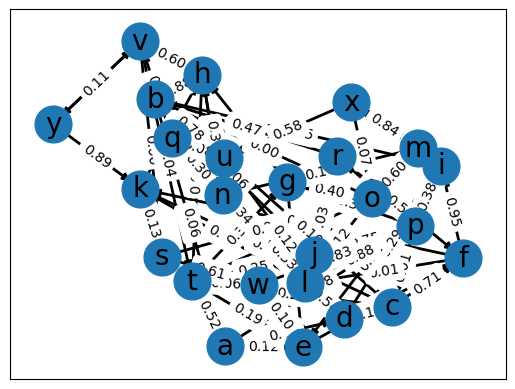

In [9]:
pos = nx.spring_layout(G, seed=23)  # positions for all nodes - seed for reproducibility
nx.draw_networkx_nodes(G, pos, node_size=700),
nx.draw_networkx_edges(G, pos, edgelist=G.edges(), width=2),
nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
edge_labels = nx.get_edge_attributes(G, "weight")
#print(edge_labels)
format_labels = {k:"%.2f"%v for k,v in edge_labels.items()}
print(format_labels)
nx.draw_networkx_edge_labels(G, pos, format_labels)
plt.show()

In [10]:
packets_in = {}
packets_out = defaultdict(int)
packets_per_node = 50
for n in G.nodes:
    packets_in[n] = packets_per_node
print(packets_in)
for epoch in tqdm(range(30)):
    for n in G.nodes:
        #print(n)
        neighbours = list(G.successors(n))
        #print(neighbours)
        weights = [G.edges[(n,neigh)]["weight"] for neigh in neighbours]
        #print(weights)
        for inp in range(packets_in[n]):
            next_hop = random.choices(neighbours, weights=weights, k=1)[0]
            packets_out[next_hop] += 1
    #print(packets_out)
    packets_in = packets_out
    packets_out = defaultdict(int)
    #break
print(packets_in)

{'a': 50, 'e': 50, 'p': 50, 'd': 50, 'b': 50, 'j': 50, 'h': 50, 'c': 50, 'k': 50, 'f': 50, 't': 50, 'i': 50, 'l': 50, 'w': 50, 'g': 50, 'v': 50, 'n': 50, 'x': 50, 's': 50, 'o': 50, 'm': 50, 'q': 50, 'r': 50, 'u': 50, 'y': 50}


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 394.59it/s]

defaultdict(<class 'int'>, {'p': 66, 'd': 27, 'e': 24, 'w': 16, 'f': 53, 't': 24, 'r': 53, 'c': 19, 'i': 108, 'l': 42, 'a': 15, 'h': 135, 'j': 3, 'v': 89, 'n': 45, 's': 40, 'k': 84, 'g': 12, 'x': 112, 'b': 69, 'o': 19, 'y': 93, 'q': 12, 'u': 75, 'm': 15})


In [12]:
try:
    print(nx.diameter(G))
    
except nx.NetworkXError:
    print("not strongly connected")

6


In [13]:
ranked = nx.pagerank(G, weight='weight', alpha=1.0)

In [14]:
nodes = list(G.nodes())
A = nx.to_numpy_array(G, nodelist=nodes, weight='weight')

In [15]:
eigvals, eigvecs = np.linalg.eig(A.T)

# Find eigenvalue closest to 1
idx = np.argmin(np.abs(eigvals - 1))

steady_state = np.real(eigvecs[:, idx])
steady_state /= steady_state.sum()

In [16]:
steady_state_dict = dict(zip(nodes, steady_state))
print(steady_state_dict)

{'a': np.float64(0.01107483999363445), 'e': np.float64(0.016660447939046717), 'p': np.float64(0.06114127321280829), 'd': np.float64(0.025531170896318338), 'b': np.float64(0.06168749425005441), 'j': np.float64(0.0035933905027248927), 'h': np.float64(0.10203171349746402), 'c': np.float64(0.010009911829206042), 'k': np.float64(0.07000227232084365), 'f': np.float64(0.03221734786494934), 't': np.float64(0.014517509753147027), 'i': np.float64(0.09085633281476674), 'l': np.float64(0.03610307241558726), 'w': np.float64(0.02314247240124579), 'g': np.float64(0.01291484541607789), 'v': np.float64(0.07566766854158108), 'n': np.float64(0.03925633668129374), 'x': np.float64(0.0851133957415449), 's': np.float64(0.026623330235532348), 'o': np.float64(0.018394028678141123), 'm': np.float64(0.011099162403838621), 'q': np.float64(0.011605921384953467), 'r': np.float64(0.03739909762236596), 'u': np.float64(0.05054616643836477), 'y': np.float64(0.07281079716450918)}


In [18]:
packets_in

defaultdict(int,
            {'p': 66,
             'd': 27,
             'e': 24,
             'w': 16,
             'f': 53,
             't': 24,
             'r': 53,
             'c': 19,
             'i': 108,
             'l': 42,
             'a': 15,
             'h': 135,
             'j': 3,
             'v': 89,
             'n': 45,
             's': 40,
             'k': 84,
             'g': 12,
             'x': 112,
             'b': 69,
             'o': 19,
             'y': 93,
             'q': 12,
             'u': 75,
             'm': 15})

In [20]:
reldiff = []
for n,p in packets_in.items():
    walk = p/sum(packets_in.values())
    print(n, walk, ranked[n], walk/ranked[n])
    reldiff.append(walk/ranked[n])
    #print(n, walk, steady_state_dict[n], walk/ranked[n])
    

p 0.0528 0.06114081539908464 0.8635802394089511
d 0.0216 0.025530976689363067 0.8460310885403447
e 0.0192 0.016660300565940134 1.1524401930210044
w 0.0128 0.023143081520072818 0.5530810574597901
f 0.0424 0.0322171817571361 1.3160679391395993
t 0.0192 0.01451746245451353 1.3225451803411175
r 0.0424 0.03739943310362427 1.1337070239145186
c 0.0152 0.010009930577748738 1.518492049663997
i 0.0864 0.09085700610754152 0.9509448274988717
l 0.0336 0.03610286138648226 0.9306741546137007
a 0.012 0.011074910317309183 1.083530218862809
h 0.108 0.10203159028272463 1.0584957041318006
j 0.0024 0.0035934267171735734 0.6678861679660831
v 0.0712 0.07566810245006192 0.94095130834012
n 0.036 0.03925652561460265 0.9170449864419156
s 0.032 0.026622693768703288 1.2019820487744215
k 0.0672 0.07000336852383887 0.9599538053246078
g 0.0096 0.012914706280576465 0.7433386243122124
x 0.0896 0.08511300313462385 1.0527181123932268
b 0.0552 0.06168700380453088 0.8948400245684422
o 0.0152 0.018394330170183774 0.82634158

In [111]:
sum(ranked.values())

0.9999999999999992

In [22]:
np.std(reldiff)

np.float64(0.2114990857084002)

In [24]:
def make_graph(n, peers=5):
    G = nx.DiGraph()
    nodes = [f"n{i:04}" for i in range(n)]
    for n in nodes:
        neighbours = [p for p in random.sample(nodes,peers) if p != n]
        weights = np.array([random.random()**2 for _ in neighbours])
        weights = weights / weights.sum()
        #print(weights)
        for p, w in zip(neighbours, weights):
            G.add_edge(n,p, weight=w)
    return G

In [27]:
nG = make_graph(10)

In [40]:
def run_simulation(G, packets_per_node=50, rounds=10):
    packets_in = {}
    packets_out = defaultdict(int)
    for n in G.nodes:
        packets_in[n] = packets_per_node
    #print(packets_in)
    for epoch in range(rounds):
        for n in G.nodes:
            #print(n)
            neighbours = list(G.successors(n))
            #print(neighbours)
            weights = [G.edges[(n,neigh)]["weight"] for neigh in neighbours]
            #print(weights)
            for inp in range(packets_in[n]):
                next_hop = random.choices(neighbours, weights=weights, k=1)[0]
                packets_out[next_hop] += 1
        #print(packets_out)
        packets_in = packets_out
        packets_out = defaultdict(int)
        #break
    return packets_in

In [34]:
resp = run_simulation(nG)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 690.72it/s]


In [35]:
def get_quality(G, packets):
    ranked = nx.pagerank(G, weight='weight', alpha=1.0)
    reldiff = []
    for n,p in packets.items():
        walk = p/sum(packets.values())
        #print(n, walk, ranked[n], walk/ranked[n])
        reldiff.append(walk/ranked[n])
    return(np.std(reldiff))

In [36]:
get_quality(nG, resp)

np.float64(0.13872356402629457)

In [68]:
def sequence_lengths(inp):
    nnodes, npeers, packets = inp
    res = {}
    for steps in [5,10,15,20,30,50,100,200]:
        res[steps] = []
        for _ in range(10):
            try:
                nG = make_graph(nnodes, peers=npeers)
                resp = run_simulation(nG, packets_per_node=packets)
                qual = get_quality(nG, resp)
                res[steps].append(qual)
            except nx.PowerIterationFailedConvergence:
                print("did not converge")
    return res

In [66]:
from multiprocessing import Pool

In [75]:
results = {}
inputs = []
for nnodes in [20,50,100,300]:
    results[nnodes] = {}
    for npeers in [5 ,10,20]:
        results[nnodes][npeers] = {}
        for packets in [10,50,100,250,1000]:
            results[nnodes][npeers][packets] = {}
            inputs.append((nnodes,npeers, packets))
        
#print(inputs)
#inputs = inputs[:3]
with Pool(processes=7) as p:
    #p.map_unordered
    for res, pos in tqdm(zip(p.imap(sequence_lengths, inputs), inputs), total=len(inputs)):
        results[pos[0]][pos[1]][pos[2]] = res
        
    #results[nnodes][npeers][packets] = sequence_lengths(nnodes, npeers, packets)
        

[(20, 5, 10), (20, 5, 50), (20, 5, 100), (20, 5, 250), (20, 5, 1000), (20, 10, 10), (20, 10, 50), (20, 10, 100), (20, 10, 250), (20, 10, 1000), (20, 20, 10), (20, 20, 50), (20, 20, 100), (20, 20, 250), (20, 20, 1000), (50, 5, 10), (50, 5, 50), (50, 5, 100), (50, 5, 250), (50, 5, 1000), (50, 10, 10), (50, 10, 50), (50, 10, 100), (50, 10, 250), (50, 10, 1000), (50, 20, 10), (50, 20, 50), (50, 20, 100), (50, 20, 250), (50, 20, 1000), (100, 5, 10), (100, 5, 50), (100, 5, 100), (100, 5, 250), (100, 5, 1000), (100, 10, 10), (100, 10, 50), (100, 10, 100), (100, 10, 250), (100, 10, 1000), (100, 20, 10), (100, 20, 50), (100, 20, 100), (100, 20, 250), (100, 20, 1000), (300, 5, 10), (300, 5, 50), (300, 5, 100), (300, 5, 250), (300, 5, 1000), (300, 10, 10), (300, 10, 50), (300, 10, 100), (300, 10, 250), (300, 10, 1000), (300, 20, 10), (300, 20, 50), (300, 20, 100), (300, 20, 250), (300, 20, 1000)]


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [21:50<00:00, 21.84s/it]


In [78]:
import json
#json.dump(results, open("results.json","w"))


In [79]:
def plot_quality_heatmap(results, nnodes, npeers, 
                         title=None, cmap='viridis', annotate=True):
    """
    Plot a 2D heatmap over packets (x-axis) and steps (y-axis).
    - Averages the last list dimension for each (packets, steps) cell.
    - `nnodes` and `npeers` select the slice.
    """
    # Gather the available keys (in case not all combos exist)
    packets_vals = sorted(results[nnodes][npeers].keys())
    # Steps are nested one level deeper
    steps_set = set()
    for p in packets_vals:
        steps_set.update(results[nnodes][npeers][p].keys())
    steps_vals = sorted(steps_set)

    # Build matrix of means (rows = steps, cols = packets)
    heat = np.full((len(steps_vals), len(packets_vals)), np.nan, dtype=float)

    for j, p in enumerate(packets_vals):
        for i, s in enumerate(steps_vals):
            try:
                arr = results[nnodes][npeers][p][s]
                if isinstance(arr, (list, tuple)) and len(arr) > 0:
                    heat[i, j] = float(np.max(arr))
            except KeyError:
                # leave as NaN if missing
                pass

    fig, ax = plt.subplots(figsize=(0.8*len(packets_vals)+4, 0.5*len(steps_vals)+3))

    # Plot; show NaNs as a distinct color (e.g., gray)
    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color='lightgray')  # for NaN cells
    im = ax.imshow(heat, aspect='auto', origin='upper', cmap=cmap_obj)

    # Axis ticks & labels
    ax.set_xticks(np.arange(len(packets_vals)))
    ax.set_xticklabels(packets_vals)
    ax.set_yticks(np.arange(len(steps_vals)))
    ax.set_yticklabels(steps_vals)

    ax.set_xlabel('packets_per_node')
    ax.set_ylabel('steps')
    ax.set_title(title or f'Quality Heatmap (nnodes={nnodes}, npeers={npeers})')

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('mean quality')

    # Optional numeric annotations
    if annotate:
        for i in range(len(steps_vals)):
            for j in range(len(packets_vals)):
                val = heat[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white',
                            fontsize=9)

    plt.tight_layout()
    plt.show()

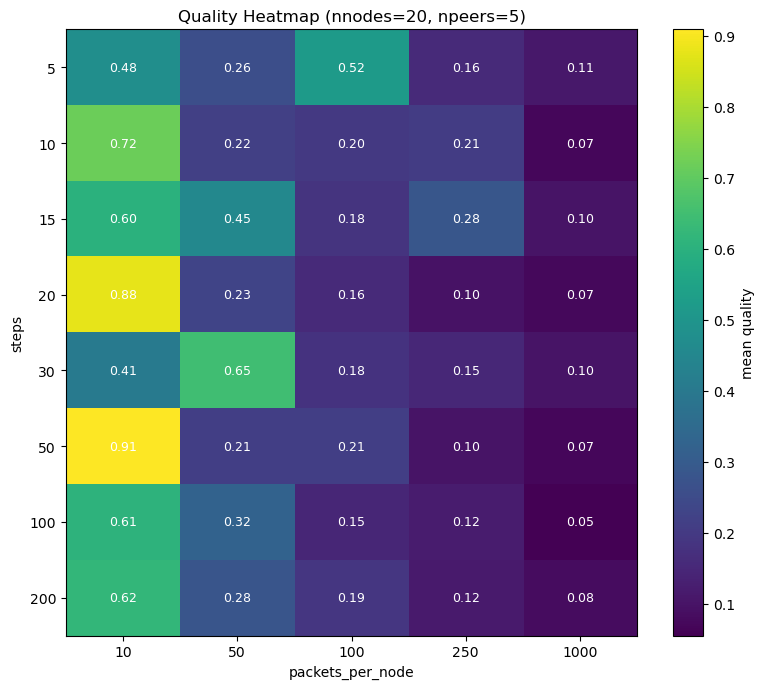

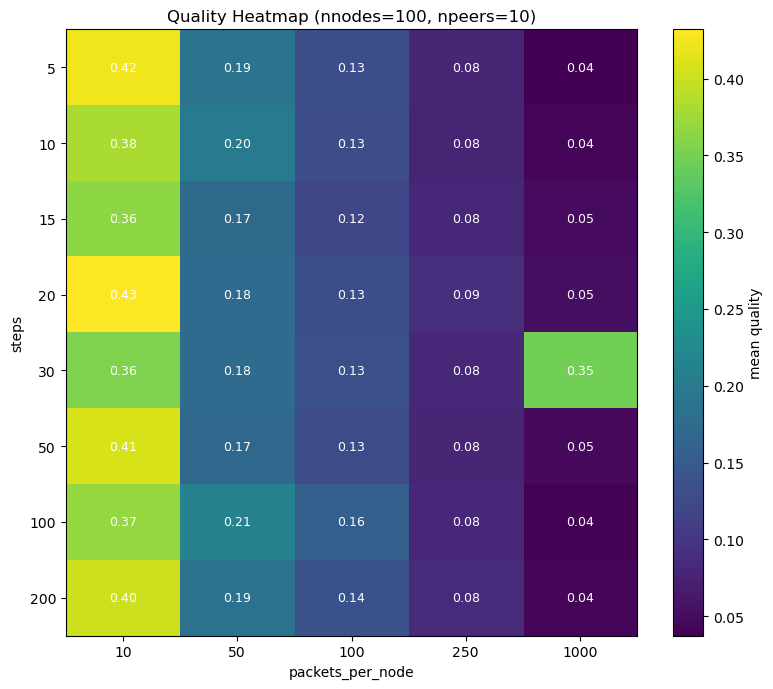

In [82]:
plot_quality_heatmap(results, 20, npeers=5)
plot_quality_heatmap(results, 100, npeers=10)